## Week 12 Exercises

###<font color=green> Replace the name below with **your name**. For full credit, your total needs to add up to 50 points.

I highly recommend reading the accompanying pdf for programming notes and other important details.

# Kavin Kannan

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi,sin,cos,exp,real,imag
import scipy

1. Solution of the heat equation The heat equation describes the flow
of heat due to a temperature gradient. In 1 spatial dimension, this is
often written as: solution is governed by the same PDE that we have
been calling the heat equation,
∂T(x, t)
∂t = D
∂
2T(x, t)
∂x2

where T(x, t) is the temperature at position x at time T, and α is the
thermal diffusivity (units m2/s). If you take a system such as a metal
rod and heat one end relative to the other, heat will flow from the hot
end to the cold end till both ends reach the same temperature.

(a) (10 points) Solve the heat equation to estimate the equilibration
time for the following problem. A steel rod (thermal diffusivity
D = 4.25 × 10−6 m2/s), of length L = 10 cm, has the left end
placed at temperature T1 = 100◦C and the right end placed at
T2 = 200◦C. The initial temperature of the rod is at a temperature
described by Ti(x) = (200 − 1000x)
◦C, in SI units for x. A rough
estimate of the time for a diffusive system like this to equilibrate
is t0 = L
2/D, which you should first compute.

(10 points) Once your program is working, plot the temperature
profile T(x) at t = 0 (initial conditions) and at a series of times
covering t  t0 to t ≈ t0. Try a logarithmic set of times such as
1,3,10,30,100,. . . or 1,2,5,10,20,50,100,. . . .

(b) (5 points) Vary the time step h, and check if the algorithm is
numerically unstable when h > a2/2D, where a is the spacing of
the grid points, and numerically stable for smaller values of h.

(c) (5 points) Double the number of space points and check that the
same condition on numerical stability holds.

For xih = 0.40, time step h = 0.0960 s


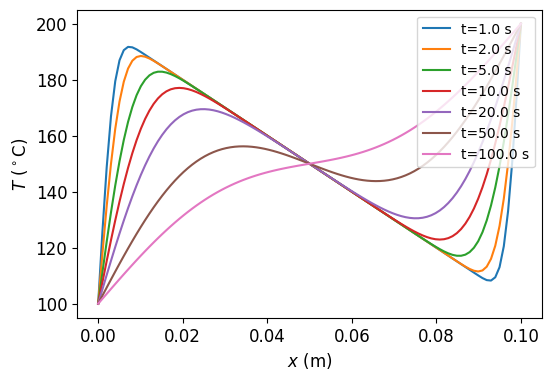

In [7]:
# Define physical system, initial and boundary conditions:
ll = 0.1                      # size of space domain (m)
dd = 4.25e-6                  # thermal diffusivity (m^2/s) (this is steel)
tt_l = 100.0                   # left fixed-temp BC (deg C)
tt_r = 200.0                   # right fixed-temp BC (deg C)
    
# Set the FTCS solution parameters:
nn = 100                      # number of space points
xih = 0.4                     # dimensionless time step, must be less than 1/2
tplot=[1,2,5,10,20,50,100]  # times at which to plot T(x) (s)

a = ll/(nn-1)             # compute space step (m)
h = xih*a**2/dd           # compute time step (s) to give specified xih
print(f'For xih = {xih:.2f}, time step h = {h:.4f} s')

# Make array to hold solution and set up with
# initial and boundary conditions:
x = np.linspace(0,ll,100)  # space points to use
tt0 = 200-1000*x
tt = tt0*np.ones(nn)      # make array for T(x), set to initial condition
tt[0] = tt_l
tt[-1] = tt_r              # ...and to boundary conditions
        
hda = h*dd/a**2           # used in FD time step
def step(tt,hda):
    """Performs one time step, updating array tt."""
    tt[1:-1] += hda*(tt[:-2] + tt[2:] - 2*tt[1:-1])

# Figure out time steps at which will plot solution:
jplot=[]
for t in tplot:
    jplot.append(int(t/h+0.5))

# Start the plot:
plt.rc('font',size=12)
plt.figure(figsize=(6,4))
plt.xlabel(r'$x$ (m)')
plt.ylabel(r'$T$ ($^\circ$C)')

# Do the simulation:
for j in range(max(jplot)+1):  # for each time step
    if j in jplot:             # if we are plotting at this time step..
        plt.plot(x,tt,label='t=%.1f s'%(j*h)) # ..add a curve to the plot
    step(tt,hda)               # do the FTCS step
plt.legend(fontsize=10)
plt.show()

For xih = 0.40, time step h = 0.1212 s


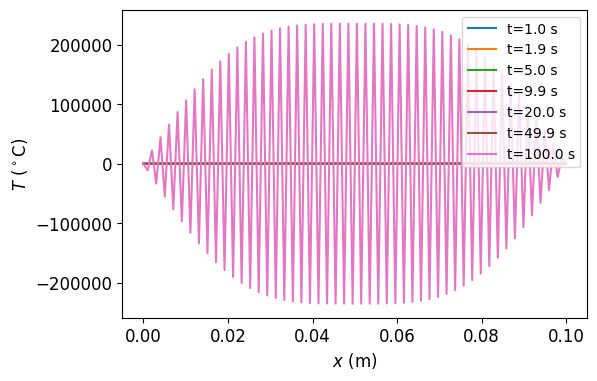

In [25]:
# Define physical system, initial and boundary conditions:
ll = 0.1                      # size of space domain (m)
dd = 4.25e-6                  # thermal diffusivity (m^2/s) (this is steel)
tt_l = 100.0                   # left fixed-temp BC (deg C)
tt_r = 200.0                   # right fixed-temp BC (deg C)
    
# Set the FTCS solution parameters:
nn = 100                      # number of space points
xih = 0.4                     # dimensionless time step, must be less than 1/2
tplot=[1,2,5,10,20,50,100]  # times at which to plot T(x) (s)

a = ll/(nn-1)             # compute space step (m)
h = a**2/(2*dd) * 1.01          # compute time step (s) to give specified xih
print(f'For xih = {xih:.2f}, time step h = {h:.4f} s')

# Make array to hold solution and set up with
# initial and boundary conditions:
x = np.linspace(0,ll,100)  # space points to use
tt0 = 200-1000*x
tt = tt0*np.ones(nn)      # make array for T(x), set to initial condition
tt[0] = tt_l
tt[-1] = tt_r              # ...and to boundary conditions
        
hda = h*dd/a**2           # used in FD time step
def step(tt,hda):
    """Performs one time step, updating array tt."""
    tt[1:-1] += hda*(tt[:-2] + tt[2:] - 2*tt[1:-1])

# Figure out time steps at which will plot solution:
jplot=[]
for t in tplot:
    jplot.append(int(t/h+0.5))

# Start the plot:
plt.rc('font',size=12)
plt.figure(figsize=(6,4))
plt.xlabel(r'$x$ (m)')
plt.ylabel(r'$T$ ($^\circ$C)')

# Do the simulation:
for j in range(max(jplot)+1):  # for each time step
    if j in jplot:             # if we are plotting at this time step..
        plt.plot(x,tt,label='t=%.1f s'%(j*h)) # ..add a curve to the plot
    step(tt,hda)               # do the FTCS step
plt.legend(fontsize=10)
plt.show()

For xih = 0.40, time step h = 0.0238 s


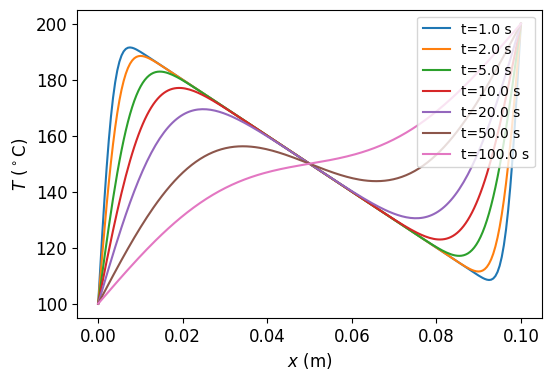

In [10]:
# Define physical system, initial and boundary conditions:
ll = 0.1                      # size of space domain (m)
dd = 4.25e-6                  # thermal diffusivity (m^2/s) (this is steel)
tt_l = 100.0                   # left fixed-temp BC (deg C)
tt_r = 200.0                   # right fixed-temp BC (deg C)
    
# Set the FTCS solution parameters:
nn = 200                      # number of space points
xih = 0.4                     # dimensionless time step, must be less than 1/2
tplot=[1,2,5,10,20,50,100]  # times at which to plot T(x) (s)

a = ll/(nn-1)             # compute space step (m)
h = xih*a**2/dd           # compute time step (s) to give specified xih
print(f'For xih = {xih:.2f}, time step h = {h:.4f} s')

# Make array to hold solution and set up with
# initial and boundary conditions:
x = np.linspace(0,ll,nn)  # space points to use
tt0 = 200-1000*x
tt = tt0*np.ones(nn)      # make array for T(x), set to initial condition
tt[0] = tt_l
tt[-1] = tt_r              # ...and to boundary conditions
        
hda = h*dd/a**2           # used in FD time step
def step(tt,hda):
    """Performs one time step, updating array tt."""
    tt[1:-1] += hda*(tt[:-2] + tt[2:] - 2*tt[1:-1])

# Figure out time steps at which will plot solution:
jplot=[]
for t in tplot:
    jplot.append(int(t/h+0.5))

# Start the plot:
plt.rc('font',size=12)
plt.figure(figsize=(6,4))
plt.xlabel(r'$x$ (m)')
plt.ylabel(r'$T$ ($^\circ$C)')

# Do the simulation:
for j in range(max(jplot)+1):  # for each time step
    if j in jplot:             # if we are plotting at this time step..
        plt.plot(x,tt,label='t=%.1f s'%(j*h)) # ..add a curve to the plot
    step(tt,hda)               # do the FTCS step
plt.legend(fontsize=10)
plt.show()

Diffusion of a tracer. The variation in space and time due to diffusion
of the concentration C(x, t) of a tracer like a dye in solution is governed
by the same PDE that we have been calling the heat equation,

∂C(x, t)
∂t = D
∂
2C(x, t)
∂x2

where D is the diffusion coefficient. D = 1.6 × 10−9 m2/s for water.
Consider a narrow tube filled with water extending from x = −L/2 to
x = L/2 where L = 1.0 mm. At t = 0, the concentration of a tracer
that diffuses according to the equation above is given by

C(x, 0) = 

C0 if |x| < x0,
0 otherwise.

Here C0 and x0 are constants describing the inital conditions. The ends
of the tube are connected to large reservoirs of water with C = 0, so
the boundary conditions are C(−L/2, t) = C(L/2, t) = 0 for all t.

(a) (20 points) Consider inital conditions x0 = 50 μm, C0 = 100 ppm
(parts per million). This describes a narrow, square “spike” of
tracer at the center of the tube. Use the FTCS algorithm to
compute and plot C(x) at 10 different times, staring with t = 0
and choosing points in the range t  t0 to t ≈ t0). Except
for very short and very long times, you should find that C(x) is
approximately a Gaussian – this is a general characteristic of
diffusive systems.
Show that the characteristic equilibration time grows as t0 =
L
2/D for this system of size L.

In [40]:
1e-3**2/1.6e-9

625.0

For xih = 0.40, time step h = 0.0255 s


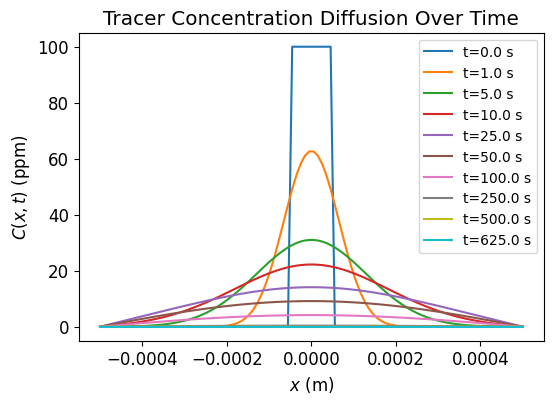

In [4]:
# Define physical system, initial and boundary conditions:
ll = 1e-3                    # size of space domain (m)
dd = 1.6e-9                  # thermal diffusivity (m^2/s)
x0 = 50e-6                 
c0 = 100

# Set the FTCS solution parameters:
nn = 100                      # number of space points
xih = 0.4                     # dimensionless time step, must be less than 1/2
tplot=[0,1,5,10,25,50,100,250,500,625]  # times at which to plot T(x) (s)

a = ll/(nn-1)             # compute space step (m)
h = xih*a**2/dd           # compute time step (s) to give specified xih
print(f'For xih = {xih:.2f}, time step h = {h:.4f} s')

# Make array to hold solution and set up with
# initial and boundary conditions:
x = np.linspace(-ll/2,ll/2,nn)  # space points to use
tt0 = np.zeros(len(x))
for i in range(len(x)):
    if np.abs(x[i]) < x0:
        tt0[i] = c0
    else:
        tt0[i] = 0
tt = tt0*np.ones(nn)      # make array for T(x), set to initial condition
           # ...and to boundary conditions
        
hda = h*dd/a**2           # used in FD time step
def step(tt,hda):
    """Performs one time step, updating array tt."""
    tt[1:-1] += hda*(tt[:-2] + tt[2:] - 2*tt[1:-1])
    tt[0] = 0
    tt[-1] = 0

# Figure out time steps at which will plot solution:
jplot=[]
for t in tplot:
    jplot.append(int(t/h+0.5))

# Start the plot:
plt.rc('font',size=12)
plt.figure(figsize=(6,4))
plt.title("Tracer Concentration Diffusion Over Time")
plt.xlabel(r'$x$ (m)')
plt.ylabel(r'$C(x,t)$ (ppm)')


# Do the simulation:
for j in range(max(jplot)+1):  # for each time step
    if j in jplot:             # if we are plotting at this time step..
        plt.plot(x,tt,label='t=%.1f s'%(j*h)) # ..add a curve to the plot
    step(tt,hda)               # do the FTCS step
plt.legend(fontsize=10)
plt.show()

In [46]:
2e-3**2/1.6e-9

2500.0

For xih = 0.40, time step h = 0.1020 s


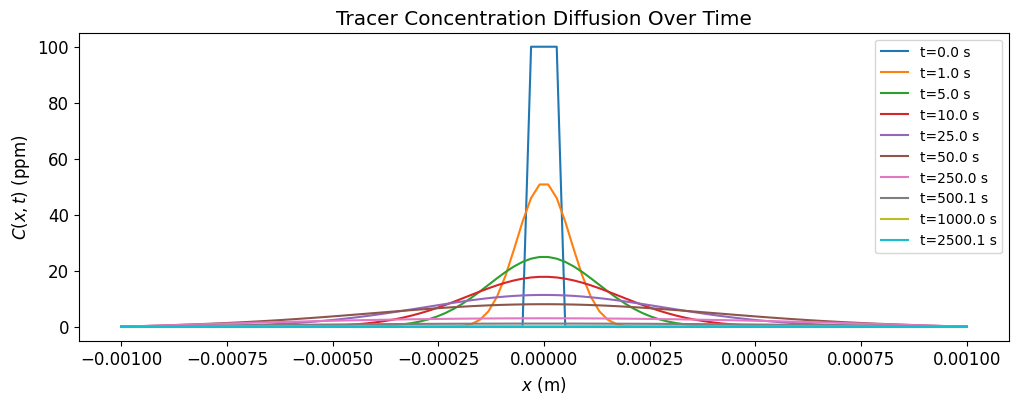

In [48]:
# Define physical system, initial and boundary conditions:
ll = 2e-3                    # size of space domain (m)
dd = 1.6e-9                  # thermal diffusivity (m^2/s)
x0 = 50e-6                 
c0 = 100

# Set the FTCS solution parameters:
nn = 100                      # number of space points
xih = 0.4                     # dimensionless time step, must be less than 1/2
tplot=[0,1,5,10,25,50,250,500,1000,2500]  # times at which to plot T(x) (s)

a = ll/(nn-1)             # compute space step (m)
h = xih*a**2/dd           # compute time step (s) to give specified xih
print(f'For xih = {xih:.2f}, time step h = {h:.4f} s')

# Make array to hold solution and set up with
# initial and boundary conditions:
x = np.linspace(-ll/2,ll/2,nn)  # space points to use
tt0 = np.zeros(len(x))
for i in range(len(x)):
    if np.abs(x[i]) < x0:
        tt0[i] = c0
    else:
        tt0[i] = 0
tt = tt0*np.ones(nn)      # make array for T(x), set to initial condition
           # ...and to boundary conditions
        
hda = h*dd/a**2           # used in FD time step
def step(tt,hda):
    """Performs one time step, updating array tt."""
    tt[1:-1] += hda*(tt[:-2] + tt[2:] - 2*tt[1:-1])
    tt[0] = 0
    tt[-1] = 0

# Figure out time steps at which will plot solution:
jplot=[]
for t in tplot:
    jplot.append(int(t/h+0.5))

# Start the plot:
plt.rc('font',size=12)
plt.figure(figsize=(12,4))
plt.title("Tracer Concentration Diffusion Over Time")
plt.xlabel(r'$x$ (m)')
plt.ylabel(r'$C(x,t)$ (ppm)')


# Do the simulation:
for j in range(max(jplot)+1):  # for each time step
    if j in jplot:             # if we are plotting at this time step..
        plt.plot(x,tt,label='t=%.1f s'%(j*h)) # ..add a curve to the plot
    step(tt,hda)               # do the FTCS step
plt.legend(fontsize=10)
plt.show()